<a href="https://colab.research.google.com/github/ZiaddRedaa/Hand-Sign-Language-/blob/main/Hand_Sign_Language.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install opendatasets

In [ ]:
import pandas as pd
import opendatasets as od
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [ ]:
import kagglehub
ash2703_handsignimages_path = kagglehub.dataset_download('ash2703/handsignimages')

print('Data source import complete.')

100%|██████████| 23.1M/23.1M [00:00<00:00, 119MB/s] 

Extracting files...


Data source import complete.


In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
train_path = '/kaggle/input/handsignimages/Train'
test_path = '/kaggle/input/handsignimages/Test'

In [ ]:
import os

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)
train_path = os.path.join(ash2703_handsignimages_path, 'Train')

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(28, 28),
    batch_size=32,
    class_mode="categorical"
)

Found 27455 images belonging to 24 classes.


In [ ]:
import os

test_datagen=ImageDataGenerator(
    rescale=1./255.
)
test_path = os.path.join(ash2703_handsignimages_path, 'Test')

validation_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(28, 28),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(28, 28),
    batch_size=32,
    class_mode='categorical'
)

Found 7172 images belonging to 24 classes.
Found 7172 images belonging to 24 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28,3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(24, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(train_generator,
                    validation_data=validation_generator,
                    epochs=50,
                    callbacks=[early_stop])

Epoch 1/50
858/858 ━━━━━━━━━━━━━━━━━━━━ 59s 66ms/step - accuracy: 0.2699 - loss: 2.3150 - val_accuracy: 0.5356 - val_loss: 1.4127
Epoch 2/50
858/858 ━━━━━━━━━━━━━━━━━━━━ 55s 64ms/step - accuracy: 0.6141 - loss: 1.1869 - val_accuracy: 0.6601 - val_loss: 1.0229
Epoch 3/50
858/858 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.7448 - loss: 0.8164 - val_accuracy: 0.8031 - val_loss: 0.6386
Epoch 4/50
858/858 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.8128 - loss: 0.6310 - val_accuracy: 0.8240 - val_loss: 0.5850
Epoch 5/50
858/858 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.8486 - loss: 0.5242 - val_accuracy: 0.8691 - val_loss: 0.4646
Epoch 6/50
858/858 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.8773 - loss: 0.4437 - val_accuracy: 0.8844 - val_loss: 0.4600
Epoch 7/50
858/858 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.8977 - loss: 0.3925 - val_accuracy: 0.9017 - val_loss: 0.3631
Epoch 8/50
858/858 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.9087 - loss: 0.3617 - 

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │        12,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 514,826 (1.96 MB)

 Trainable params: 171,608 (670.34 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 343,218 (1.31 MB)

In [ ]:
loss, accuracy = model.evaluate(test_generator)
print(f'Test loss: {loss}')
print(f'Test accuracy: {accuracy}')

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9562 - loss: 0.2391
Test loss: 0.23912665247917175
Test accuracy: 0.9562186002731323


In [ ]:
train_loss, train_accuracy = model.evaluate(train_generator, verbose=0)
print(f"Train loss: {train_loss:}")
print(f"Train accuracy: {train_accuracy:}")

Train loss: 0.17850014567375183
Train accuracy: 0.9691131114959717


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


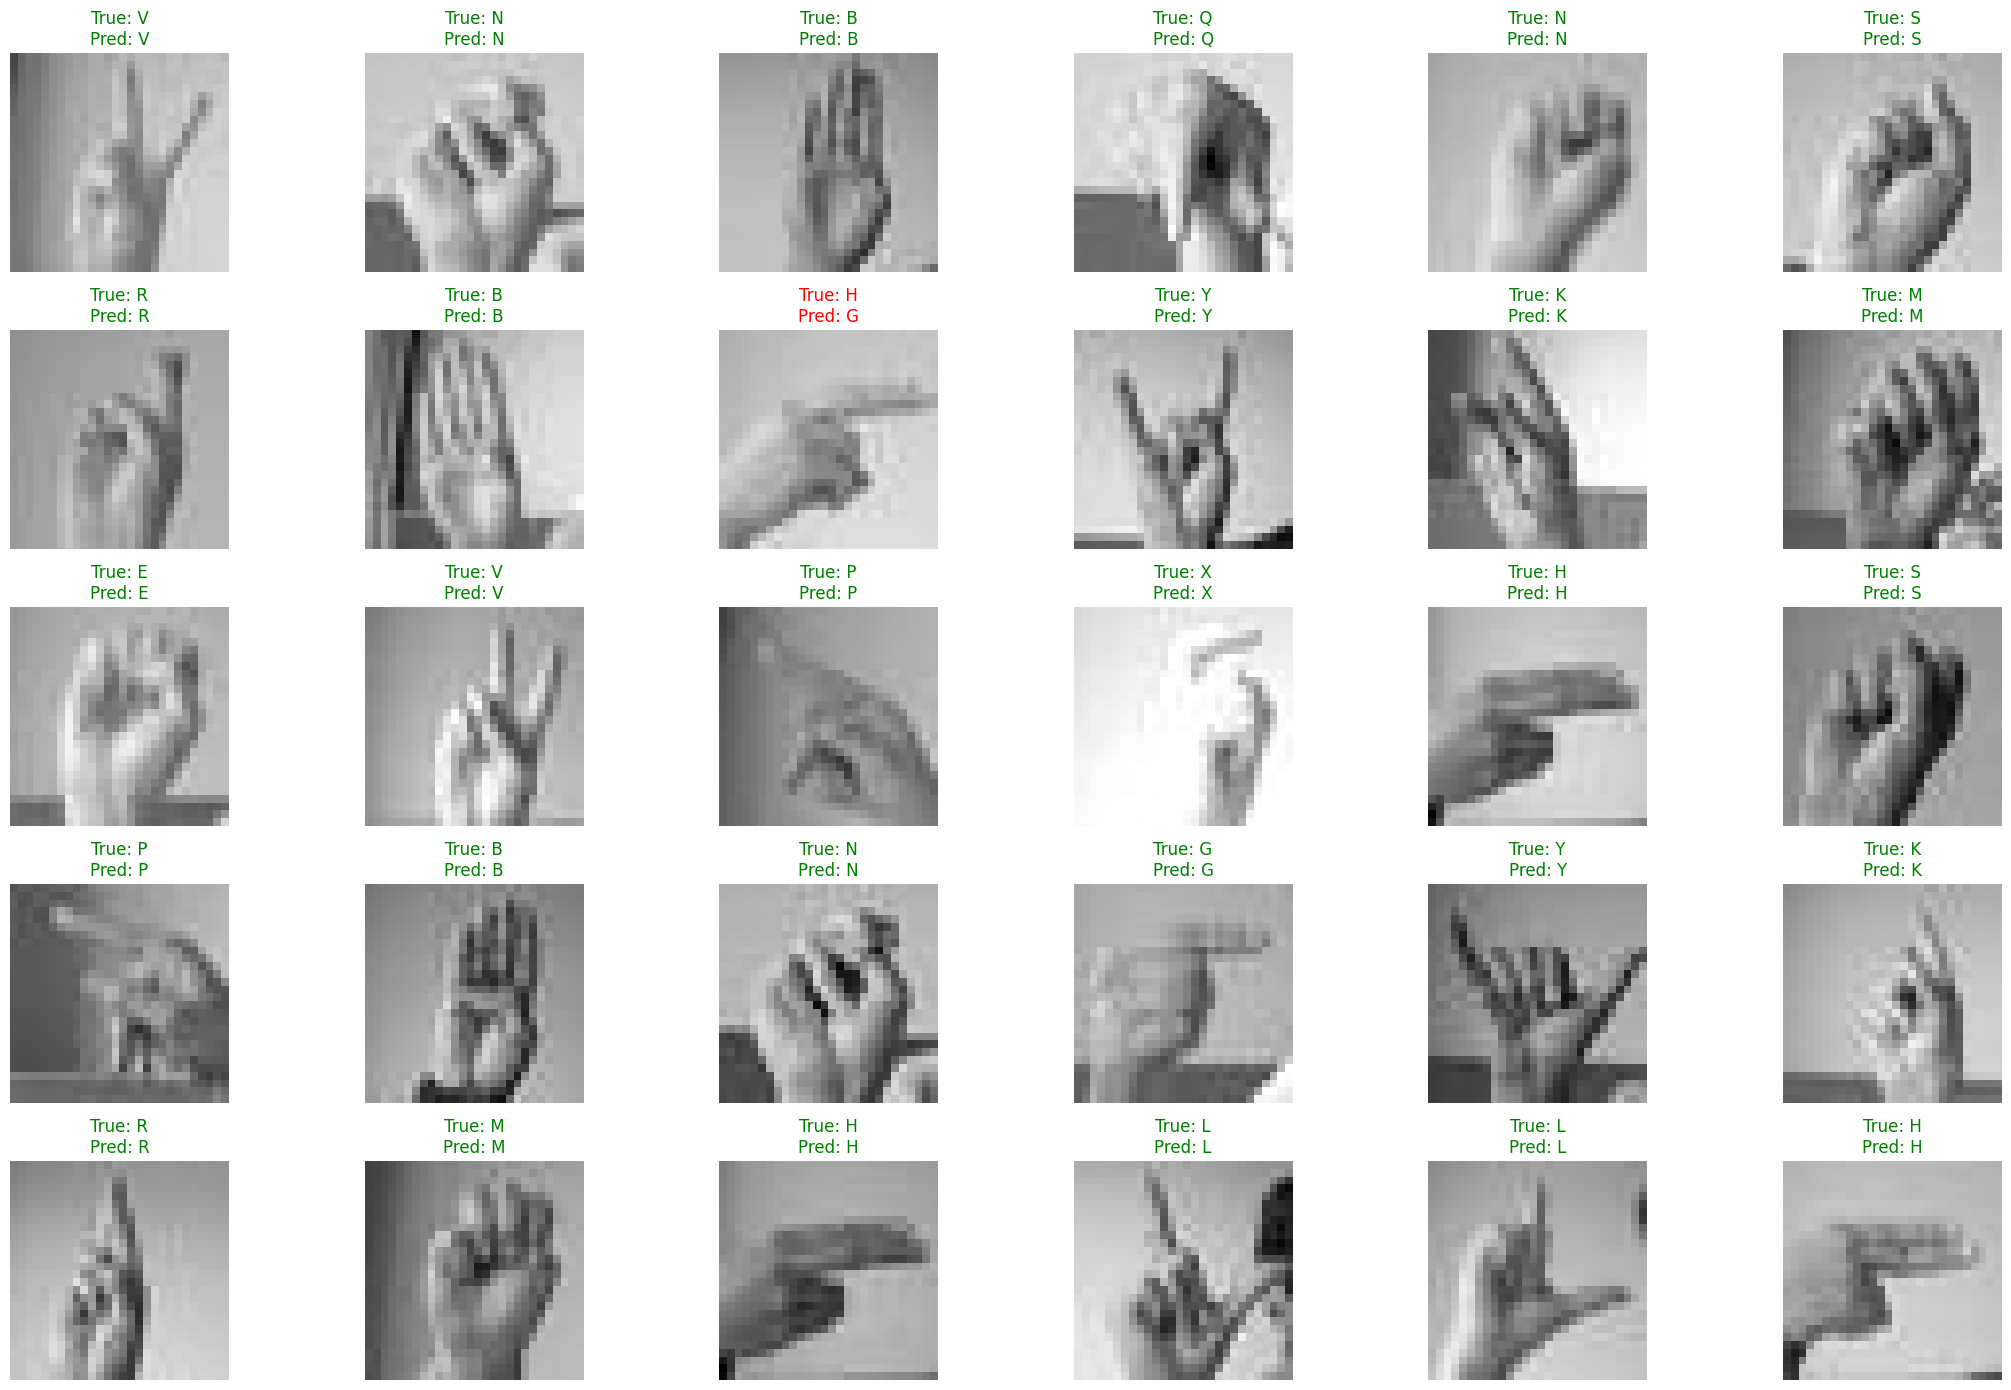

✅ Correct: 29 (96.67%)
❌ Wrong:   1 (3.33%)


In [ ]:
# Get class names from the generator
class_names = list(validation_generator.class_indices.keys())

# Grab a batch of validation images and labels
X_batch, y_batch = next(validation_generator)

# Predict on this batch
predictions = model.predict(X_batch)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_batch, axis=1)

# Pick random images from the batch
num_images = 30
indices = np.random.choice(len(X_batch), num_images, replace=False)

# Counters
correct = 0
wrong = 0

plt.figure(figsize=(22, 14))

for i, idx in enumerate(indices):
    plt.subplot(5, 6, i + 1)   # 4 rows × 5 cols = 20 images

    img = X_batch[idx]

    # Show image (already scaled to [0,1])
    plt.imshow(img)
    plt.axis('off')

    # Labels
    true_label = class_names[true_classes[idx]]
    predicted_label = class_names[predicted_classes[idx]]

    # Check correctness
    if true_label == predicted_label:
        color = 'green'
        correct += 1
    else:
        color = 'red'
        wrong += 1

    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)

plt.tight_layout()
plt.show()

# Show statistics
total = correct + wrong
acc_percent = (correct / total) * 100
wrong_percent = (wrong / total) * 100

print("======"*25)
print(f"✅ Correct: {correct} ({acc_percent:.2f}%)")
print(f"❌ Wrong:   {wrong} ({wrong_percent:.2f}%)")

In [ ]:
model.save('model.h5')
print("Model saved successfully!")

Model saved successfully!


In [ ]:

import streamlit as st
from PIL import Image
import numpy as np
import tensorflow as tf
import cv2

# --- Load Your Trained Model ---
# Make sure your model file is in the same folder as this script.
try:
    model = tf.keras.models.load_model('model.h5') # Corrected model filename
except Exception as e:
    st.error(f"Error loading model: {e}")
    model = None

# --- App Title and Description ---
st.title("🤟 Hand Sign Language Classifier")
st.write("Upload an image of a hand sign, and the model will predict which letter it represents.")

# --- Class Labels ---
# This list maps the model's output index to the corresponding letter.
class_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']

# --- Image Upload Widget ---
uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

# --- Image Preprocessing Function ---
def preprocess_image(image):
    """
    Correctly processes an image into the format the model expects,
    handling different input image formats (e.g., RGBA, Grayscale, RGB).
    """
    # 1. Convert the uploaded PIL image to a NumPy array.
    image_array = np.array(image)

    # 2. Handle different image formats before processing.
    # First, check if the image is already grayscale (2 dimensions).
    if image_array.ndim == 2:
        # It's already grayscale, assign it directly.
        gray_image = image_array
    # Next, check if it has an alpha channel (4 channels).
    elif image_array.shape[2] == 4:
        # Convert from RGBA to RGB to drop the alpha channel.
        rgb_image = cv2.cvtColor(image_array, cv2.COLOR_RGBA2RGB)
        # Now convert from RGB to grayscale.
        gray_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)
    # Otherwise, assume it's a standard 3-channel RGB image.
    else:
        gray_image = cv2.cvtColor(image_array, cv2.COLOR_RGB2GRAY)

    # 3. Resize the image to the model's expected size (28x28).
    resized_image = cv2.resize(gray_image, (28, 28))

    # 4. Convert the 1-channel grayscale image back to a 3-channel image.
    # This step is necessary if your model was trained on 3-channel images.
    three_channel_image = cv2.cvtColor(resized_image, cv2.COLOR_GRAY2BGR)

    # 5. Reshape for the model to add the batch dimension.
    # The final shape will be (1, 28, 28, 3).
    reshaped_image = np.expand_dims(three_channel_image, axis=0)

    # 6. Normalize the pixel values.
    normalized_image = reshaped_image / 255.0

    return normalized_image

# --- Main App Logic ---
# This part runs when a user uploads a file and a model is successfully loaded.
if uploaded_file is not None and model is not None:
    # Display the user's uploaded image.
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Image', use_container_width=True)
    st.write("")
    st.write("Classifying...")

    # Preprocess the image to the correct format.
    processed_image = preprocess_image(image)

    # Make a prediction.
    prediction = model.predict(processed_image)

    # Get the top prediction's index and confidence score.
    predicted_class_index = np.argmax(prediction)
    confidence = np.max(prediction)

    # Safely get the predicted label.
    if 0 <= predicted_class_index < len(class_labels):
        predicted_class_label = class_labels[predicted_class_index]
        # Display the final result.
        st.success(f"**Prediction:** {predicted_class_label}")
        st.write(f"**Confidence:** {confidence:.2f}")
    else:
        st.error(f"Error: The model produced an invalid prediction index ({predicted_class_index}).")

2026-05-29 19:13:05.631 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 19:13:05.632 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 19:13:05.634 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 19:13:05.635 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 19:13:05.636 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 19:13:05.639 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 19:13:05.640 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 19:13:05.642 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar